### 1. Imports

In [1]:
# Import libraries
import gym
import numpy as np
from stable_baselines3 import PPO, A2C, DQN
from matplotlib import pyplot as plt

In [2]:
# Import classes
from rl_environment_q_learning import Environment

The TensorFlow contrib module will not be included in TensorFlow 2.0.
For more information, please see:
  * https://github.com/tensorflow/community/blob/master/rfcs/20180907-contrib-sunset.md
  * https://github.com/tensorflow/addons
  * https://github.com/tensorflow/io (for I/O related ops)
If you depend on functionality not listed there, please file an issue.



c:\users\patri\documents\github\reinforcementlearninginventorymanagement\venv_37\lib\site-packages\stable_baselines\__init__.py:33: UserWarning: stable-baselines is in maintenance mode, please use [Stable-Baselines3 (SB3)](https://github.com/DLR-RM/stable-baselines3) for an up-to-date version. You can find a [migration guide](https://stable-baselines3.readthedocs.io/en/master/guide/migration.html) in SB3 documentation.
  "stable-baselines is in maintenance mode, please use [Stable-Baselines3 (SB3)](https://github.com/DLR-RM/stable-baselines3) for an up-to-date version. You can find a [migration guide](https://stable-baselines3.readthedocs.io/en/master/guide/migration.html) in SB3 documentation."


### Environment creation

In [3]:
# Parameters
number_of_regional_warehouses = 1
max_inventory_amount_regional_warehouses = 25
max_inventory_amount_central_warehouse = 100
customer_demand_per_step = 1
simulation_length = 40
lead_time = 2

In [4]:
env = Environment(number_of_regional_wh = number_of_regional_warehouses, 
                  rw_inventory_limit = max_inventory_amount_regional_warehouses, 
                  cw_inventory_limit = max_inventory_amount_central_warehouse,
                  demand = customer_demand_per_step,
                  sim_length = simulation_length,
                  lead_time = lead_time)

Simulation created with the following parameters:
------------------------------------------------------------
central_warehouse ; Inventory: 33
regional_warehouse_1 ; ID: 1 ; Inventory: 8 ; Demand: 1 ; Lost sales: 0
------------------------------------------------------------


### RL model training

###### Model 1: PPO
Proximal Policy Optimization
https://openai.com/blog/openai-baselines-ppo/

In [5]:
ppo_model = DQN("MlpPolicy", env)
ppo_model.learn(total_timesteps=100000)

###### Learning Curve

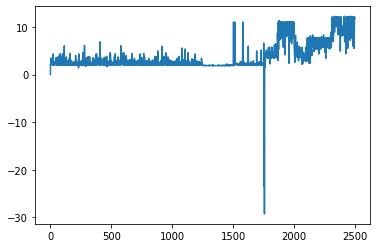

[0, 2.2426474371039595, 2.001120208294122, 2.2536777814399307, 2.470472040037258, 3.4810076013784452, 2.507698673688376, 2.3114839222562344, 2.287406668875912, 3.287537970323002, 2.1338322898142525, 2.5832735380561473, 2.490136000312336, 2.2694415784108206, 2.2006278197057583, 2.5018457540425505, 3.348572069074491, 1.9825487797226935, 3.081894974874514, 2.624285096829854, 2.338407656192688, 3.296055010969199, 2.3306913528881497, 4.34198376058216, 2.0973194613974004, 2.08921483210856, 1.9676130708853825, 2.4664816287793814, 1.9647489325110816, 2.212997875055353, 2.1091401692936227, 2.3971963092844106, 2.2337925776531247, 2.4455154157698242, 2.7284712488420926, 2.7344485159177583, 1.9926985991678419, 2.181115606996615, 2.3170661322195856, 2.1779101870968214, 2.2505761026413205, 2.5268368302178374, 2.1637694003473387, 2.9709307194204215, 2.165684968252609, 2.2592520315269007, 2.887483697745846, 3.574093375888705, 2.0684963114987354, 2.645835463350606, 3.402445897381959, 2.1658726494710483

In [6]:
plt.plot(env.total_reward)
plt.show()
print(env.total_reward)

### Run simulation

In [7]:
# Reset environment for simulation
state = env.reset()
done = False

# Graph data
inventory_levels = []
actions = []

# Run simulation with model
while not done:
    action, _states = ppo_model.predict(state)
    state, reward, done, info = env.step(action)
    
    inventory_levels.append(info["Inventory:"])
    actions.append(info["Action:"])
    
    for i in info:
        print(i, info[i], end=" | ")
    print()
    
print("\n", env.evaluation_parameters())

Steps left: 39 | Inventory: 7 | Action: 0 | Shipment: 0 | Reward: 0.12 | 
Steps left: 38 | Inventory: 6 | Action: 0 | Shipment: 0 | Reward: 0.14 | 
Steps left: 37 | Inventory: 5 | Action: 0 | Shipment: 0 | Reward: 0.17 | 
Steps left: 36 | Inventory: 4 | Action: 0 | Shipment: 0 | Reward: 0.2 | 
Steps left: 35 | Inventory: 3 | Action: 0 | Shipment: 0 | Reward: 0.25 | 
Steps left: 34 | Inventory: 2 | Action: 0 | Shipment: 0 | Reward: 0.33 | 
Steps left: 33 | Inventory: 1 | Action: 1 | Shipment: 1 | Reward: 0.5 | 
Steps left: 32 | Inventory: 0 | Action: 1 | Shipment: 1 | Reward: 1 | 
Steps left: 31 | Inventory: 4 | Action: 0 | Shipment: 1 | Reward: 0.2 | 
Steps left: 30 | Inventory: 8 | Action: 0 | Shipment: 0 | Reward: 0.11 | 
Steps left: 29 | Inventory: 7 | Action: 0 | Shipment: 0 | Reward: 0.12 | 
Steps left: 28 | Inventory: 6 | Action: 0 | Shipment: 0 | Reward: 0.14 | 
Steps left: 27 | Inventory: 5 | Action: 0 | Shipment: 0 | Reward: 0.17 | 
Steps left: 26 | Inventory: 4 | Action: 0 | 

###### Inventory level graph

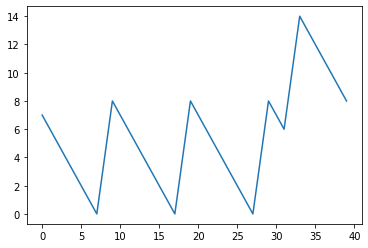

[7, 6, 5, 4, 3, 2, 1, 0, 4, 8, 7, 6, 5, 4, 3, 2, 1, 0, 4, 8, 7, 6, 5, 4, 3, 2, 1, 0, 4, 8, 7, 6, 10, 14, 13, 12, 11, 10, 9, 8]
[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, array(1), array(1), 0, 0, 0, 0, 0, 0, array(1), 0]


In [8]:
plt.plot(inventory_levels)
plt.show()
print(inventory_levels)
print(actions)